In [3]:
# Import required packages
using JuMP, Ipopt, Plots, Printf, LinearAlgebra, SCS, COSMO, Distributions, LightGraphs, FileIO, VideoIO

# Include helper files
include("../twocells/twocells_vis.jl")
include("../twocells/twocells_setup.jl")
include("../twocells/twocells_nonlinearsolver.jl")
include("../twocells/twocells_hittingtime.jl")
include("../utils/ctmc_vis.jl")
include("../utils/ctmc_core.jl")
include("../utils/file_utils.jl")
include("../utils/video_utils.jl");


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

(0, 0, 0, 0)->7.621081245815218
(0, 1, 0, 0)->5.50576843539275
(0, 2, 0, 0)->4.0812756848375065
(1, 0, 0, 0)->5.50576843539275
(1, 1, 0, 0)->15.262289974459906
(1, 2, 0, 0)->23.512533470651114
(1, 3, 0, 0)->34.31923517587039
(2, 0, 0, 0)->4.0812756848375065
(2, 1, 0, 0)->23.512533470651114
(2, 2, 0, 0)->47.33704484993269
(2, 3, 0, 0)->91.44648036355383
(3, 1, 0, 0)->34.31923517587039
(3, 2, 0, 0)->91.44648036355383
(0, 0, 0, 1)->7.513610714155778
(0, 1, 0, 1)->10.355562816355837
(0, 2, 0, 1)->11.843006450284646
(1, 0, 0, 1)->3.2424645103538907
(1, 1, 0, 1)->8.722344361545657
(1, 2, 0, 1)->12.30755901888954

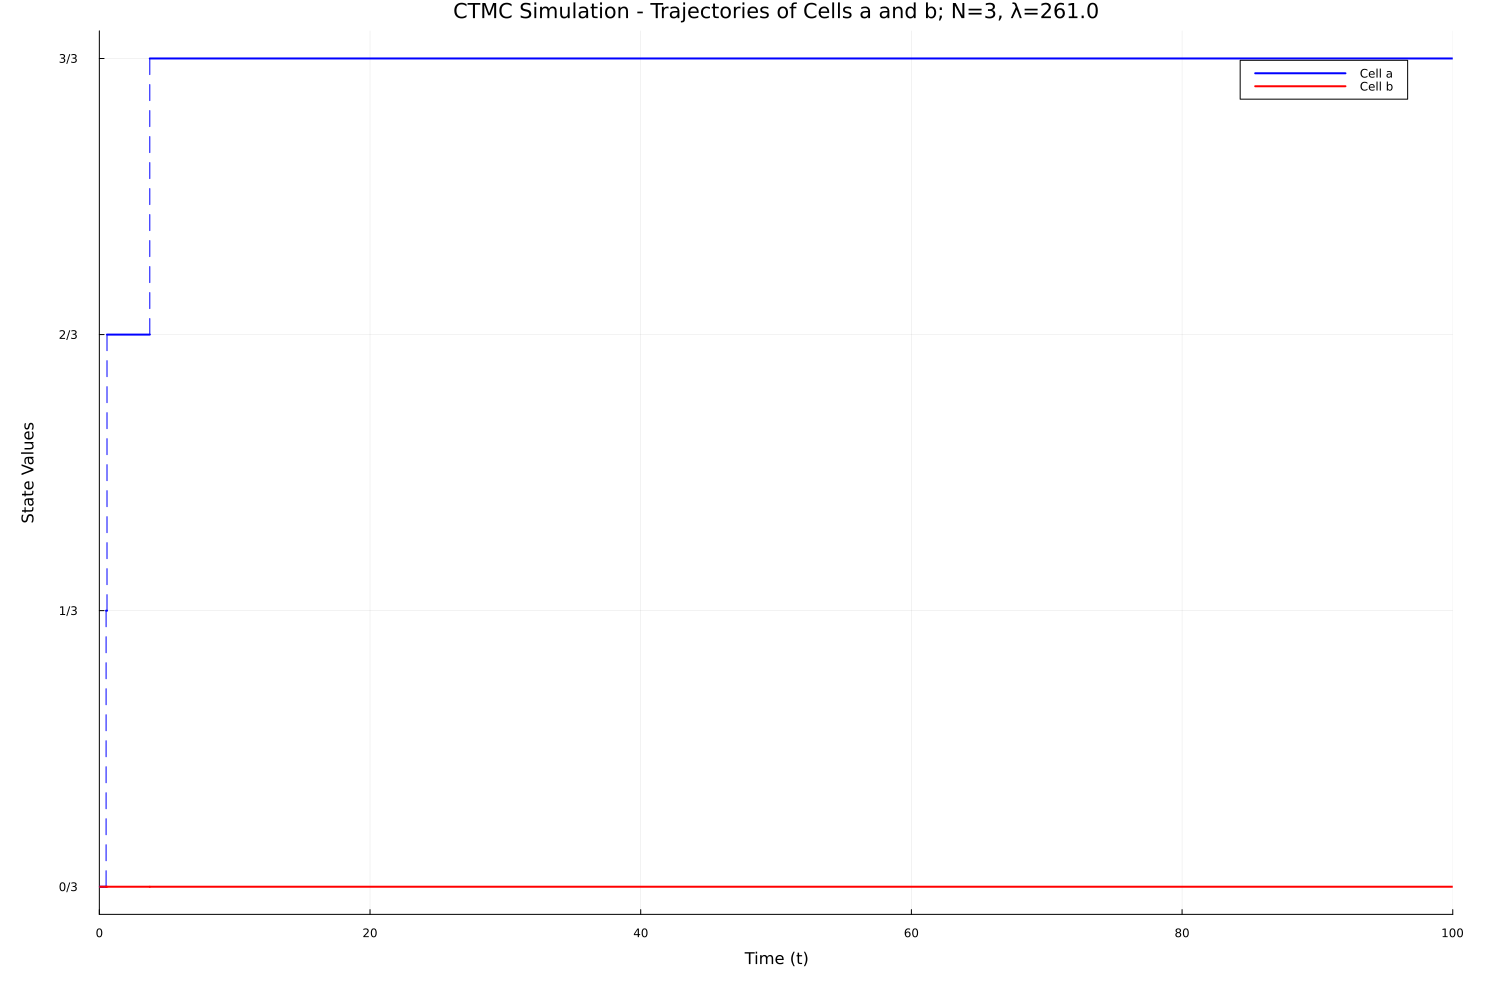

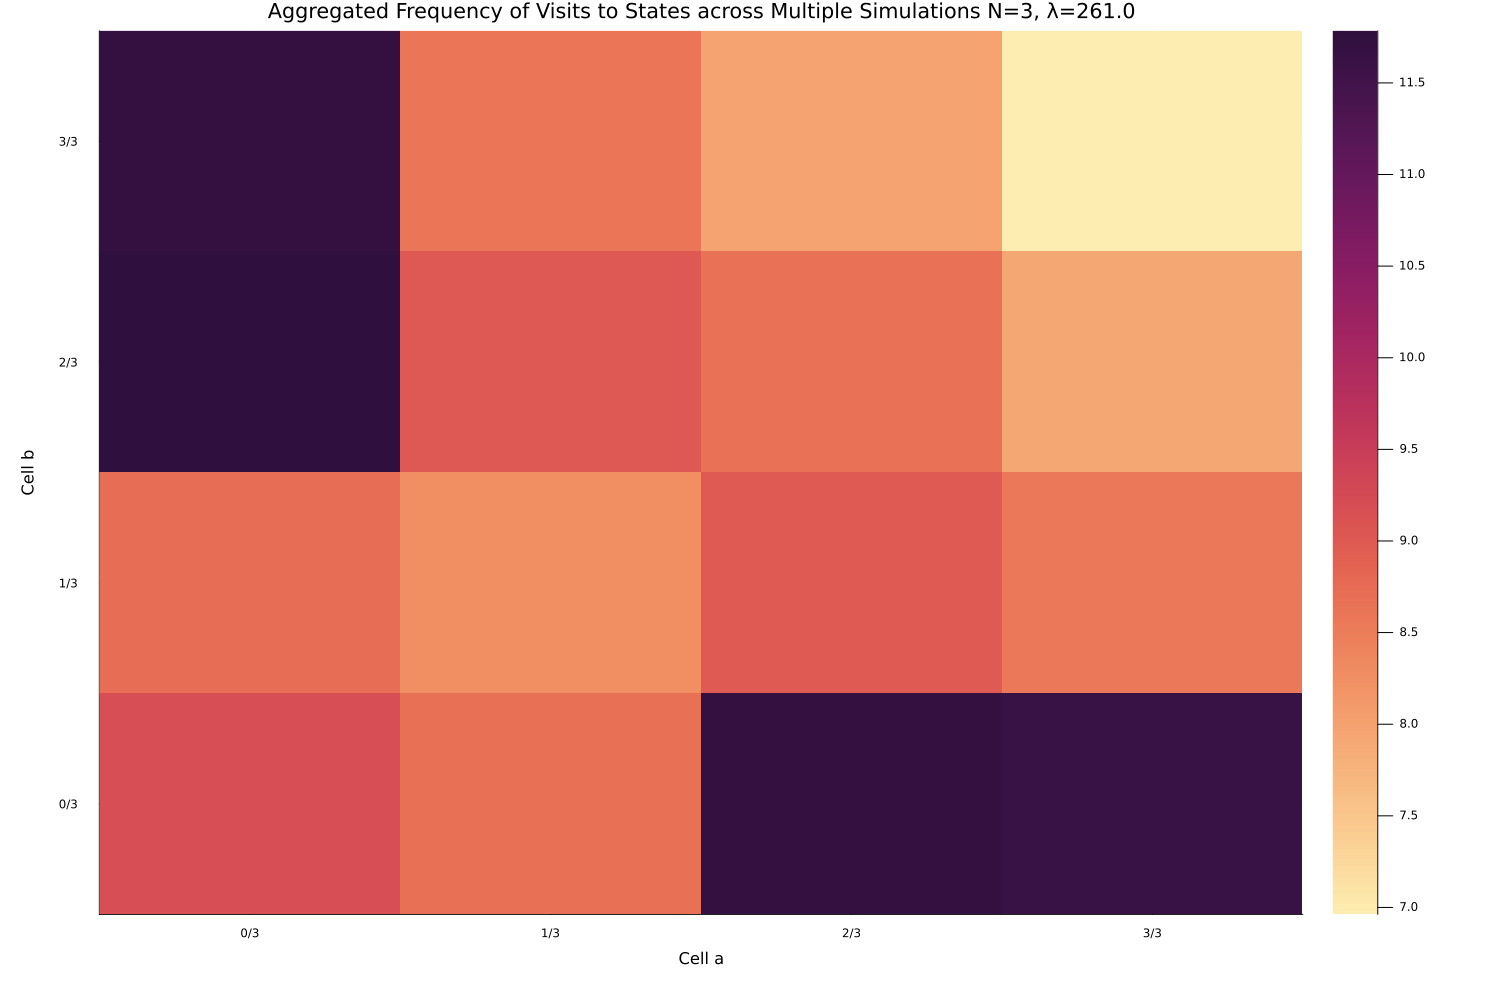

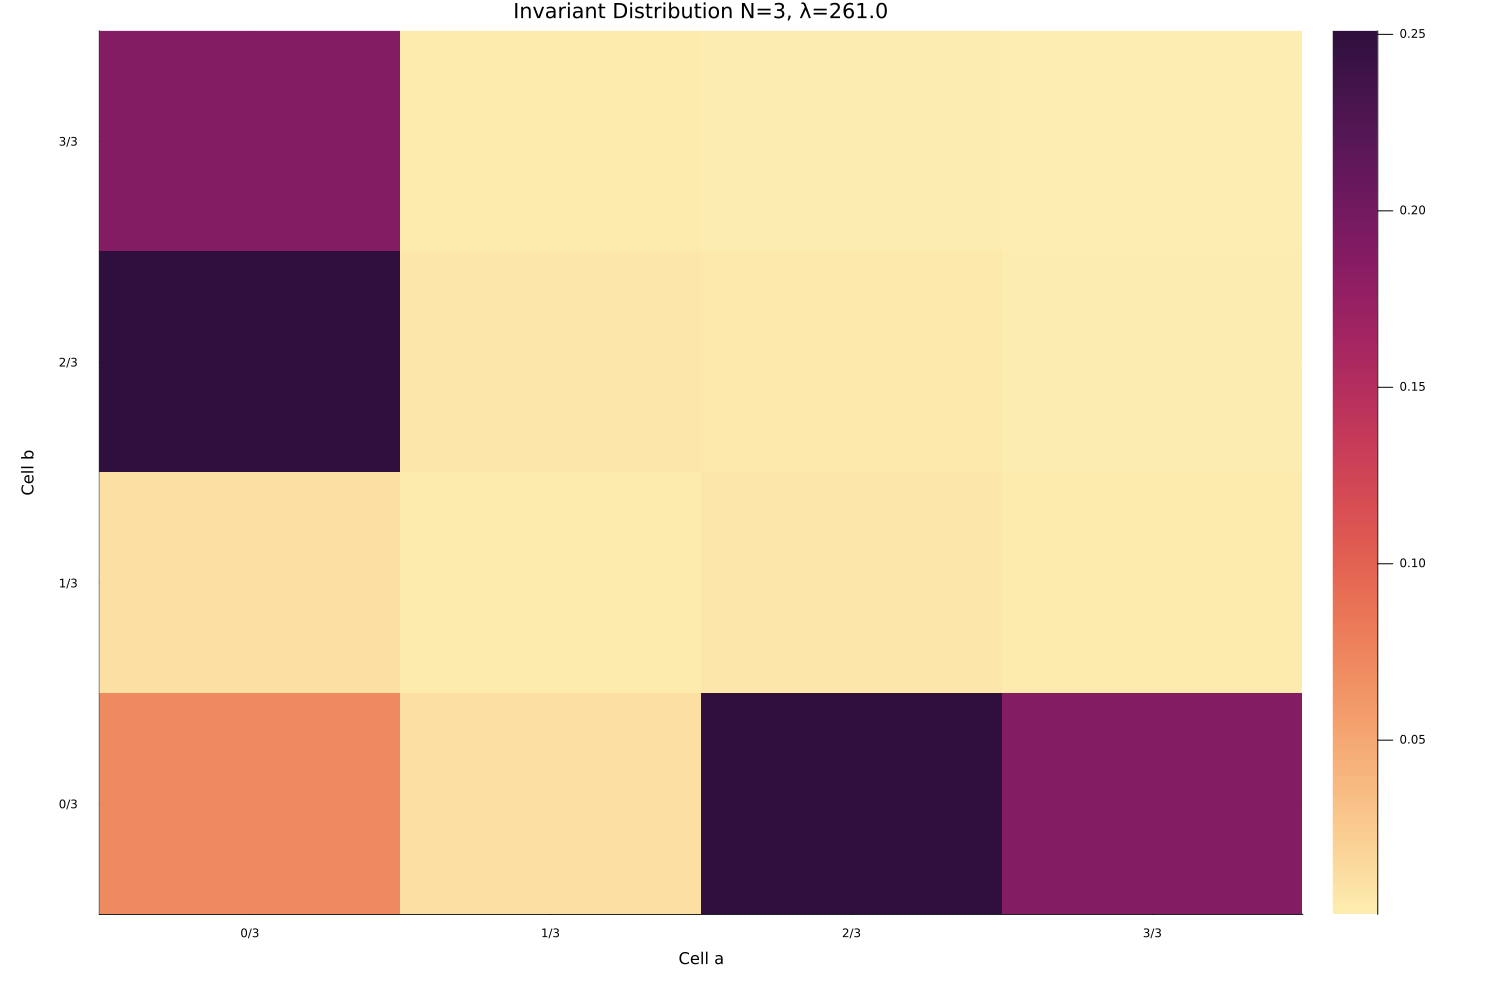

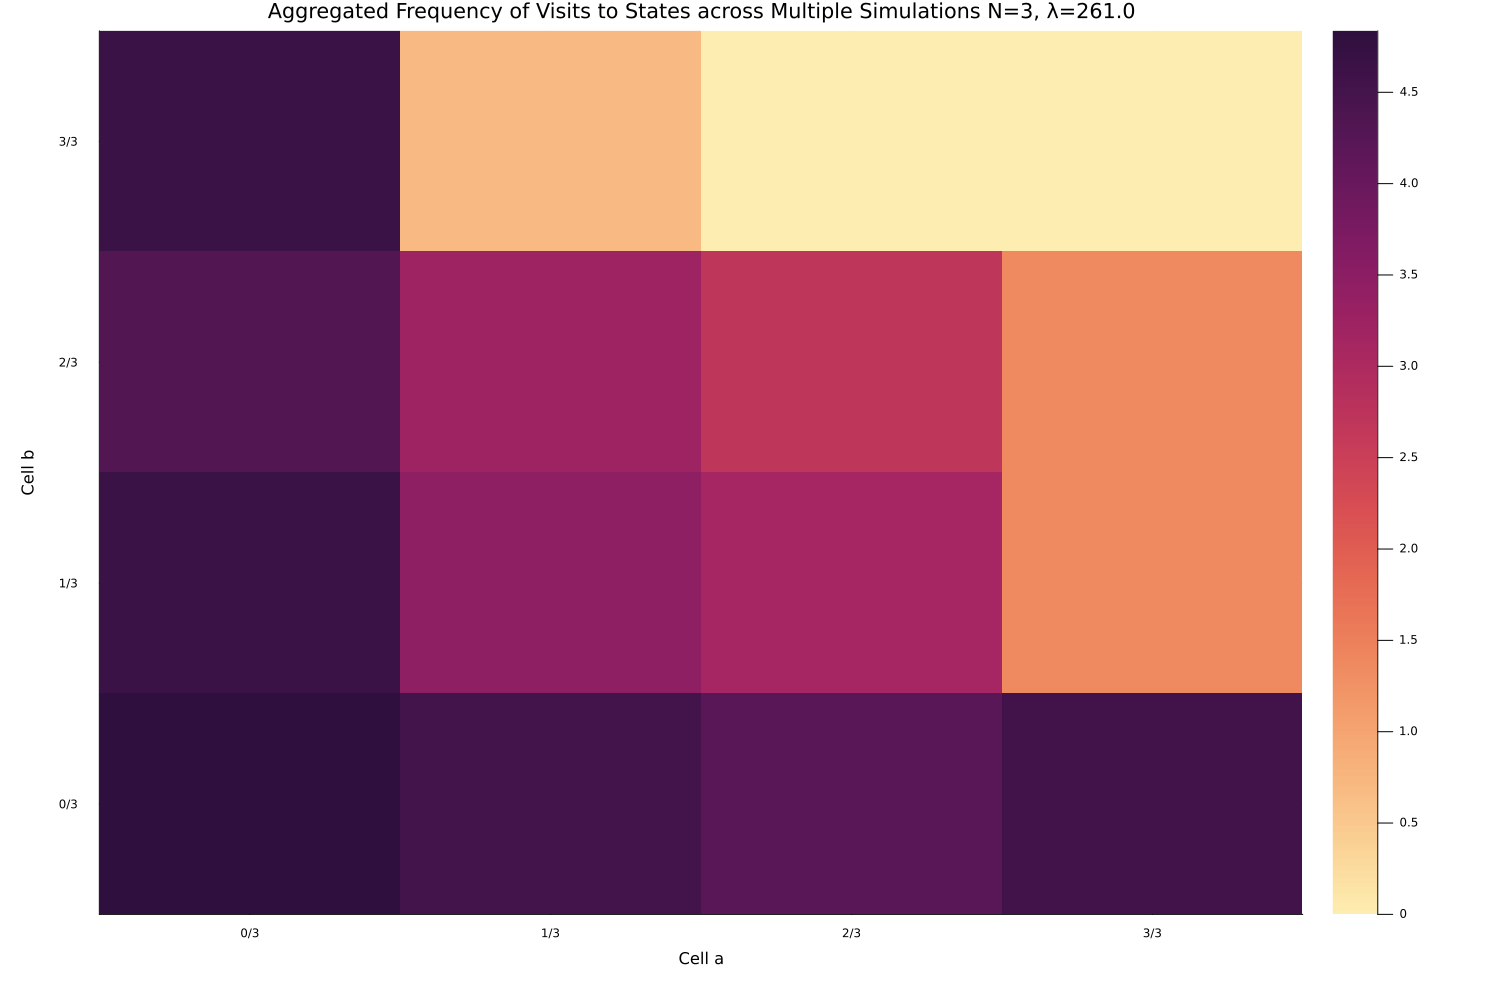

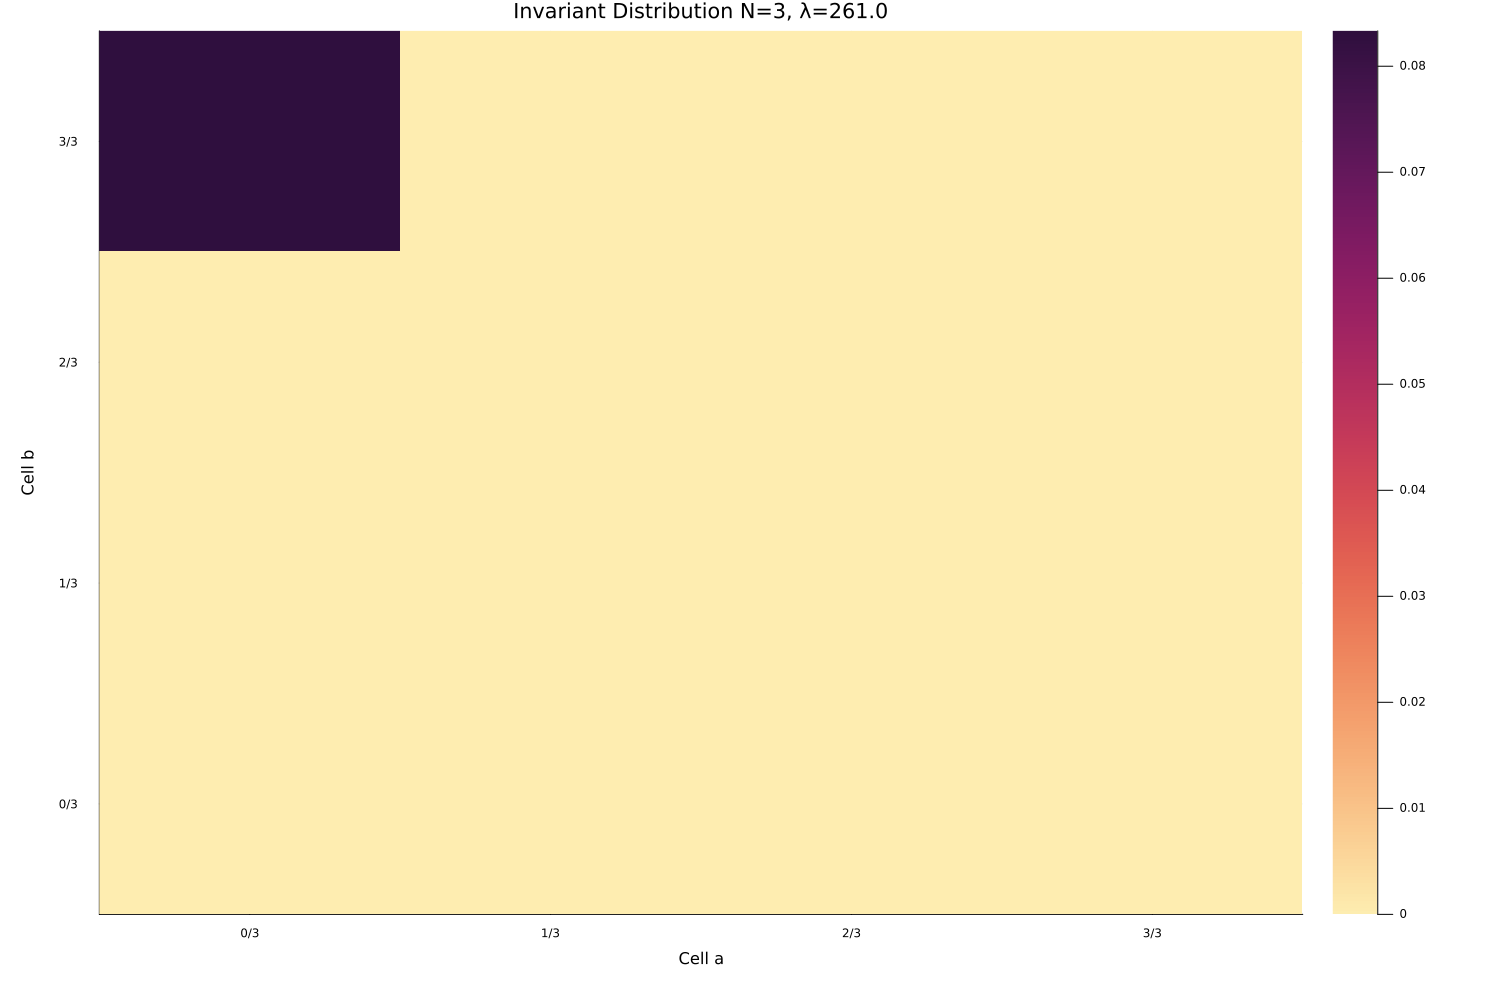

In [2]:
# Set problem parameters
N = 3  # Number of states - 1
λ = 261.0  # Lambda parameter
initial_tau_val=10.0  # Initial tau value for optimization
initial_P_val=1.0  # Initial P value for optimization

# Create output directory
lambda_str = replace(string(λ), "." => "_")
base_folder = joinpath(dirname(@__DIR__), "experiments", "results", "Interior_point_method_results")
folder_name = joinpath(base_folder, @sprintf("Interior_Point_Method_results_N_%d_lambda_%s", N, lambda_str))
mkpath(folder_name)

# Get state matrices and sizes
S,Skeyer,T,TG,TB,Tc=statematrices(N);
ni,np,ns,nt=varioussizes(N)

# Define state sets
targetstates_good=[target_state+1 for target_state ∈ TG];  # Good target states
targetstates_bad=[target_state+1 for target_state ∈ TB];   # Bad target states
targetstates=[targetstates_good;targetstates_bad]          # All target states
startstates=[start_state+1 for start_state ∈ Tc];         # Starting states
allstates=[startstates;targetstates_good; targetstates_bad]
all_targetstates = vcat(targetstates_good, targetstates_bad)

# Run nonlinear solver to get optimal solution
upper_bound_tau_0,upper_bound,tau_opt,P_opt,terminationstatus=run_nonlinear_solver(N, λ, initial_P_val, initial_tau_val,false,false)

# Extract results
tau_opt_tilde = tau_opt[startstates]
lower_bound=minimum(tau_opt_tilde)

# Clean up P_opt values
P_opt_ = P_opt .* (abs.(P_opt) .>= 1e-8)  # Zero out small values
P_opt_ .= min.(P_opt_, 1.0)                # Cap at 1.0
Q_opt = Q_maker_using_M(P_opt_, N, λ, S, Skeyer)  # Generate Q matrix

# Print results for each start state
for start_state_idx in startstates
    println(S[start_state_idx-1],"->",tau_opt[start_state_idx])
end
println(terminationstatus,", Optimal: ", tau_opt[1],", Upper bound: ", upper_bound,", Lower Bound: ",lower_bound)
println("Is Q irreducible? ", is_irreducible(Q_opt))

# Plot Q matrix heatmap
Q_filename = generate_filename(folder_name,"Q_matrix_heatmap")
plot_Q_with_colored_yticks(Q_opt, N, all_targetstates, Q_filename, λ, save_plots=false)

# Simulate CTMC
initial_state = 1
T = 100.0
println("absorbing states: ", all_targetstates)
Q_opt_copy = copy(Q_opt)
Q_opt_absorbing=Q_absorbing_states_maker(Q_opt_copy, all_targetstates)
times, states = simulate_ctmc(Q_opt, initial_state, T)
times_absorbing, states_absorbing = simulate_ctmc(Q_opt_absorbing, initial_state, T)

# Plot single CTMC simulation
println("Plotting single ctmc simulation...")
ctmc_simulation_filename = generate_filename(folder_name,"single_ctmc_simulation")
plot_ctmc_our_problem(times_absorbing, states_absorbing, T, N, ctmc_simulation_filename, λ, save_plots=true)

# Parameters for multiple simulations
num_simulations = 100
T=1000.0
initial_state = 1

# Plot multiple CTMC simulations
println("Plotting multiple ctmc simulation...")
T = 7000.0
longtime_heatmap_simulation_filename = generate_filename(folder_name,"multiple_ctmc_simulation_heatmap_longtime")
plot_ctmc_our_problem_multi(Q_opt, initial_state, T, N, num_simulations, longtime_heatmap_simulation_filename, λ, save_plots=true)

# Plot invariant distribution
println("Plotting invariant ctmc heatmap...")
invariant_heatmap_simulation_filename = generate_filename(folder_name,"invariant_ctmc_heatmap")
plot_ctmc_invar_distn_our_problem(Q_opt, N, invariant_heatmap_simulation_filename, λ, save_plots=true)

# Plot multiple CTMC simulations with absorbing states
println("Plotting multiple ctmc simulation with absorbing states...")
T = 7000.0
longtime_heatmap_simulation_filename = generate_filename(folder_name,"multiple_ctmc_simulation_heatmap_longtime_absorbing")
plot_ctmc_our_problem_multi(Q_opt_absorbing, initial_state, T, N, num_simulations, longtime_heatmap_simulation_filename, λ, save_plots=true)

# Plot invariant distribution with absorbing states
println("Plotting invariant ctmc heatmap with absorbing states...")
invariant_heatmap_simulation_filename = generate_filename(folder_name,"invariant_ctmc_heatmap_absorbing") 
plot_ctmc_invar_distn_our_problem(Q_opt_absorbing, N, invariant_heatmap_simulation_filename, λ, save_plots=true)

# Print final optimal solution details
# Print to console
println("================================================")
println("Optimal solution")
println("P_opt: ", P_opt_)
println("tau_opt_0: ", tau_opt[1])
println("------------------------------------------------")
println("F^+(.,0): ", P_opt_[1:(N)])
println("F^+(.,1): ", P_opt_[N+1:2*(N)])
println("F^-(.,0): ", P_opt_[2*(N)+1:3*(N)])
println("F^-(.,1): ", P_opt_[3*(N)+1:4*(N)])
println("G: ", P_opt_[4*(N)+1:end-1])
println("k_off: ", P_opt_[end])

# Save to txt file
optimal_values_filename = generate_filename(folder_name, "optimal_values_w_o_fixed_values.txt")
open(optimal_values_filename, "w") do io
    println(io, "tau_opt_0 = ", tau_opt[1])
    println(io, "k_off = ", P_opt_[end])
    println(io, "F+(.,0) = ", P_opt_[1:N])
    println(io, "F+(.,1) = ", P_opt_[N+1:2*N])
    println(io, "F-(.,0) = ", P_opt_[2*N+1:3*N])
    println(io, "F-(.,1) = ", P_opt_[3*N+1:4*N])
    println(io, "G = ", P_opt_[4*N+1:end-1])
end